# MCQ Uncertainty Experiments
### When Should a Language Model Trust Itself?

This notebook runs **four modular experiments** on Qwen2.5-7B-Instruct (4-bit):

| # | Experiment  | Goal |
|---|-----------|------|
| 1 | **Baseline** | Accuracy + uncertainty signals (margin, entropy) |
| 2 | **Confidence Scoring** | Two-pass: answer normally, then ask model to self-report confidence |
| 3 | **Oracle Retry** | When model is wrong, retry — upper bound of reflection |
| 4 | **When to Reflect** | Can uncertainty signals predict errors? (ROC/AUC analysis) |

>
**Modular**: Each experiment saves results to disk. Run them independently.

---

## 0. Setup & Imports

In [ ]:
!pip install -q -U "bitsandbytes>=0.46.1" "accelerate" "transformers" "sentencepiece" "safetensors" "scikit-learn"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 165.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 166.7 MB/s eta 0:00:00


In [ ]:
import os, re, ast, json, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score, f1_score
from sklearn.calibration import calibration_curve

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from tqdm.auto import tqdm

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('Setup complete.')

Setup complete.


### Mount Drive & Set Paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = Path('/content/drive/MyDrive/NLP Project')
print('Drive mounted. DATA_DIR:', DATA_DIR)

Mounted at /content/drive
Drive mounted. DATA_DIR: /content/drive/MyDrive/NLP Project


### Load Model

In [ ]:
MODEL_NAME = 'Qwen/Qwen2.5-7B-Instruct'

# Derive a clean folder name from the model
MODEL_SHORT = MODEL_NAME.split('/')[-1]  # e.g. 'Qwen2.5-7B-Instruct'

# All outputs go under a model-specific folder
RESULTS_DIR = Path('results') / MODEL_SHORT
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Model:       {MODEL_NAME}')
print(f'Results dir: {RESULTS_DIR}')

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map='auto',
    quantization_config=quant_config,
    trust_remote_code=True,
)
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f'Loaded: {MODEL_NAME}')

Model:       Qwen/Qwen2.5-7B-Instruct
Results dir: results/Qwen2.5-7B-Instruct


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Loaded: Qwen/Qwen2.5-7B-Instruct


### Load Dataset

In [ ]:
df = pd.read_csv(DATA_DIR / "combined_dataset.csv")
df["choice_labels"] = df["choice_labels"].apply(ast.literal_eval)
df["choice_texts"]  = df["choice_texts"].apply(ast.literal_eval)

print(f"Dataset: {len(df)} questions")
print(df["source"].value_counts())

Dataset: 1500 questions
source
MMLU        250
AQUA-RAT    250
ReClor      250
MedQA       250
ARC-Easy    250
SciQ        250
Name: count, dtype: int64


### Shared Utilities
Used across all experiments.

In [ ]:
def normalize_label(text: str) -> str:
    text = str(text).strip().upper()
    match = re.search(r"\\b([A-Z])\\b", text)
    if match:
        return match.group(1)
    if text and text[0].isalpha():
        return text[0]
    return text


def build_system_prompt(valid_labels: list) -> str:
    label_list = ", ".join(valid_labels)
    return (
        "You are a multiple-choice question answering system. "
        "Read the question and options carefully. "
        f"Return only the final answer label, one of {label_list}. "
        "Do not explain your reasoning."
    )


def build_messages(question: str, options: dict) -> list:
    option_lines = [f"{label}. {text}" for label, text in options.items()]
    valid_labels = list(options.keys())
    user_prompt = (
        f"Question:\n{question}\n\n"
        f"Options:\n" + "\n".join(option_lines) + "\n\n"
        "Answer with only the label."
    )
    return [
        {"role": "system", "content": build_system_prompt(valid_labels)},
        {"role": "user", "content": user_prompt},
    ]


def build_retry_messages(question: str, options: dict, prev_label: str) -> list:
    option_lines = [f"{label}. {text}" for label, text in options.items()]
    valid_labels = list(options.keys())
    user_prompt = (
        f"Question:\n{question}\n\n"
        f"Options:\n" + "\n".join(option_lines) + "\n\n"
        "Answer with only the label."
    )
    return [
        {"role": "system", "content": build_system_prompt(valid_labels)},
        {"role": "user",      "content": user_prompt},
        {"role": "assistant", "content": prev_label},
        {"role": "user",      "content": (
            f"Your answer \'{prev_label}\' is incorrect. "
            "Please reconsider and provide a different answer label."
        )},
    ]


def build_prompt_text(messages: list) -> str:
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True,
    )


def get_label_token_ids(label: str) -> list:
    token_ids = []
    for cand in [label, f" {label}"]:
        ids = tokenizer(cand, add_special_tokens=False)["input_ids"]
        if len(ids) == 1:
            token_ids.append(ids[0])
    token_ids = list(dict.fromkeys(token_ids))
    if not token_ids:
        raise ValueError(f"Label \'{label}\' has no single-token encoding.")
    return token_ids


def infer(messages: list, options: dict) -> dict:
    """Single inference call: 1-token greedy + logit scoring."""
    option_labels = list(options.keys())
    prompt_text = build_prompt_text(messages)
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
    prompt_len = inputs["input_ids"].shape[1]

    with torch.inference_mode():
        gen_out = model.generate(
            **inputs, max_new_tokens=1, do_sample=False,
            return_dict_in_generate=True, output_scores=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    seq = gen_out.sequences[0]
    generated_text = tokenizer.decode(seq[prompt_len:], skip_special_tokens=True).strip()
    generated_label = normalize_label(generated_text)

    step_scores = gen_out.scores[0][0]
    probs_vocab = torch.softmax(step_scores, dim=-1)
    log_probs_vocab = torch.log_softmax(step_scores, dim=-1)
    entropy_vocab = float(-(probs_vocab * torch.log(probs_vocab + 1e-12)).sum().item())

    label_scores = {}
    for label in option_labels:
        cand_ids = get_label_token_ids(label)
        cand_lps = torch.tensor([log_probs_vocab[tid].item() for tid in cand_ids], dtype=torch.float32)
        label_scores[label] = torch.logsumexp(cand_lps, dim=0).item()

    label_logprob_tensor = torch.tensor([label_scores[l] for l in option_labels], dtype=torch.float32)
    label_probs_tensor = torch.softmax(label_logprob_tensor, dim=0)
    label_prob_dict = {label: float(label_probs_tensor[i].item()) for i, label in enumerate(option_labels)}

    sorted_labels = sorted(label_prob_dict.items(), key=lambda x: x[1], reverse=True)
    top1_label, top1_prob = sorted_labels[0]
    top2_label, top2_prob = sorted_labels[1] if len(sorted_labels) > 1 else (None, None)
    margin = float(top1_prob - top2_prob) if top2_prob is not None else None
    entropy_labels = float(-(label_probs_tensor * torch.log(label_probs_tensor + 1e-12)).sum().item())

    return {
        "generated_label": generated_label,
        "predicted_by_probs": top1_label,
        "label_probs": label_prob_dict,
        "label_scores": label_scores,
        "top1_prob": top1_prob,
        "top2_label": top2_label,
        "top2_prob": top2_prob,
        "margin": margin,
        "entropy_over_labels": entropy_labels,
        "entropy_over_vocab": entropy_vocab,
    }

print("Utilities loaded.")

Utilities loaded.


---
# Experiment 1 — Baseline

**Goal**: Measure raw model accuracy and uncertainty signal distributions.

**Collected per question**: predicted label, `top1_prob`, `margin`, `entropy_over_labels`, `entropy_over_vocab`


In [ ]:
# ── Run Baseline ──
BASELINE_JSONL = RESULTS_DIR / 'baseline.jsonl'
BASELINE_CSV   = RESULTS_DIR / 'baseline_summary.csv'

already_done = set()
if BASELINE_JSONL.exists():
    with open(BASELINE_JSONL) as f:
        for line in f:
            try: already_done.add(json.loads(line)['row_id'])
            except: pass
    print(f'Resuming: {len(already_done)} rows done.')

if BASELINE_CSV.exists() and len(already_done) == len(df):
    print('Baseline complete. Loading...')
    baseline_df = pd.read_csv(BASELINE_CSV)
else:
    summary_rows = []
    if BASELINE_JSONL.exists():
        with open(BASELINE_JSONL) as f:
            for line in f:
                try:
                    rec = json.loads(line)
                    summary_rows.append({k: v for k, v in rec.items() if k not in ('label_probs', 'label_scores')})
                except: pass

    for idx, row in tqdm(df.iterrows(), total=len(df), desc='Exp1: Baseline'):
        if int(idx) in already_done: continue
        question = row['question']
        options = dict(zip(row['choice_labels'], row['choice_texts']))
        gold = normalize_label(str(row['gold_label']))
        source = row.get('source', 'unknown')

        msgs = build_messages(question, options)
        out = infer(msgs, options)
        pred_gen = normalize_label(out['generated_label'])
        pred_prob = normalize_label(out['predicted_by_probs'])

        record = {
            'row_id': int(idx), 'source': source, 'gold_label': gold,
            'pred_generated': pred_gen, 'pred_by_probs': pred_prob,
            'correct_generated': int(pred_gen == gold),
            'correct_by_probs': int(pred_prob == gold),
            'top1_prob': out['top1_prob'], 'top2_prob': out['top2_prob'],
            'margin': out['margin'],
            'entropy_over_labels': out['entropy_over_labels'],
            'entropy_over_vocab': out['entropy_over_vocab'],
        }
        with open(BASELINE_JSONL, 'a') as f:
            f.write(json.dumps(record) + '\n')
        summary_rows.append({k: v for k, v in record.items() if k not in ('label_probs', 'label_scores')})

    baseline_df = pd.DataFrame(summary_rows)
    baseline_df.to_csv(BASELINE_CSV, index=False)
    print(f'Saved: {BASELINE_CSV}')

print(f'Baseline: {baseline_df.shape}')
print(baseline_df.head(3))

Exp1: Baseline:   0%|          | 0/1500 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Saved: results/Qwen2.5-7B-Instruct/baseline_summary.csv
Baseline: (1500, 12)
   row_id source gold_label pred_generated pred_by_probs  correct_generated  \
0       0   MMLU          B              B             B                  1   
1       1   MMLU          D              D             D                  1   
2       2   MMLU          D              D             D                  1   

   correct_by_probs  top1_prob     top2_prob    margin  entropy_over_labels  \
0                 1   0.999986  1.380484e-05  0.999972             0.000169   
1                 1   0.721584  2.784026e-01  0.443182             0.591597   
2                 1   0.999999  5.547419e-07  0.999999             0.000010   

   entropy_over_vocab  
0            0.000169  
1            0.591603  
2            0.000010  


### 1a — Overall and Per-Source Accuracy

Overall accuracy — greedy decode : 0.713
Overall accuracy — prob argmax   : 0.713

          correct_generated  correct_by_probs
source                                       
AQUA-RAT              0.408             0.408
ARC-Easy              0.976             0.976
MMLU                  0.892             0.892
MedQA                 0.540             0.540
ReClor                0.496             0.496
SciQ                  0.964             0.964


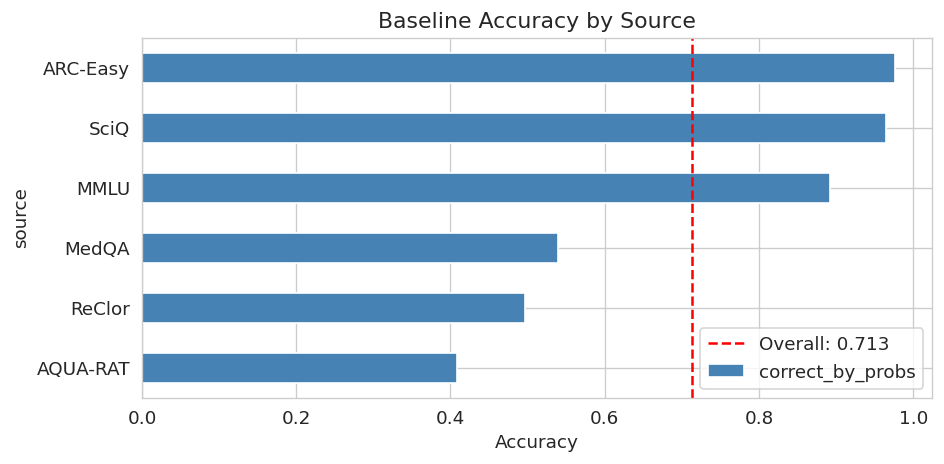

In [ ]:
# ── Accuracy ──
acc_gen = baseline_df["correct_generated"].mean()
acc_prb = baseline_df["correct_by_probs"].mean()
print(f"Overall accuracy — greedy decode : {acc_gen:.3f}")
print(f"Overall accuracy — prob argmax   : {acc_prb:.3f}")
print()
print(baseline_df.groupby("source")[["correct_generated", "correct_by_probs"]].mean())

# Bar chart
per_src = baseline_df.groupby("source")["correct_by_probs"].mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
per_src.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Accuracy")
ax.set_title("Baseline Accuracy by Source")
ax.axvline(acc_prb, color="red", linestyle="--", label=f"Overall: {acc_prb:.3f}")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_accuracy_per_source.png", dpi=150)
plt.show()

### 1b — Uncertainty Signal Distributions

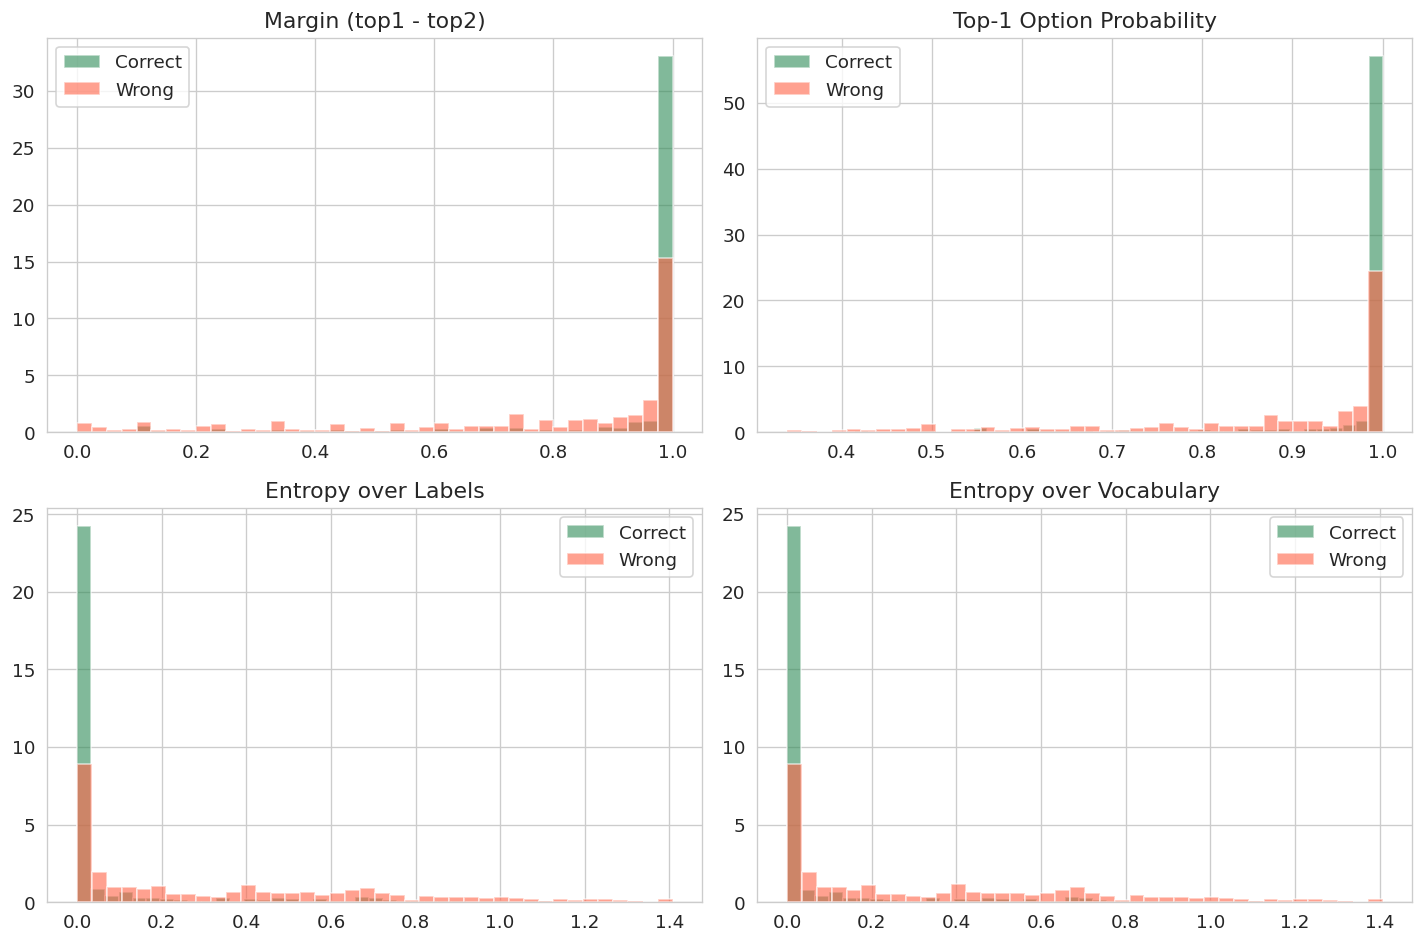


Mean values per signal:
  Margin (top1 - top2)                correct=0.9414  wrong=0.7630
  Top-1 Option Probability            correct=0.9687  wrong=0.8671
  Entropy over Labels                 correct=0.0791  wrong=0.3348
  Entropy over Vocabulary             correct=0.0792  wrong=0.3356


In [ ]:
correct = baseline_df[baseline_df["correct_by_probs"] == 1]
wrong   = baseline_df[baseline_df["correct_by_probs"] == 0]

signals = {
    "margin":              ("Margin (top1 - top2)", True),
    "top1_prob":           ("Top-1 Option Probability", True),
    "entropy_over_labels": ("Entropy over Labels", False),
    "entropy_over_vocab":  ("Entropy over Vocabulary", False),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (col, (title, _)) in zip(axes.flatten(), signals.items()):
    ax.hist(correct[col].dropna(), bins=40, alpha=0.6, label="Correct", color="seagreen", density=True)
    ax.hist(wrong[col].dropna(), bins=40, alpha=0.6, label="Wrong", color="tomato", density=True)
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_signal_distributions.png", dpi=150)
plt.show()

print("\nMean values per signal:")
for col, (title, _) in signals.items():
    print(f"  {title:<35} correct={correct[col].mean():.4f}  wrong={wrong[col].mean():.4f}")

### 1c — Calibration (Reliability Diagram + ECE)

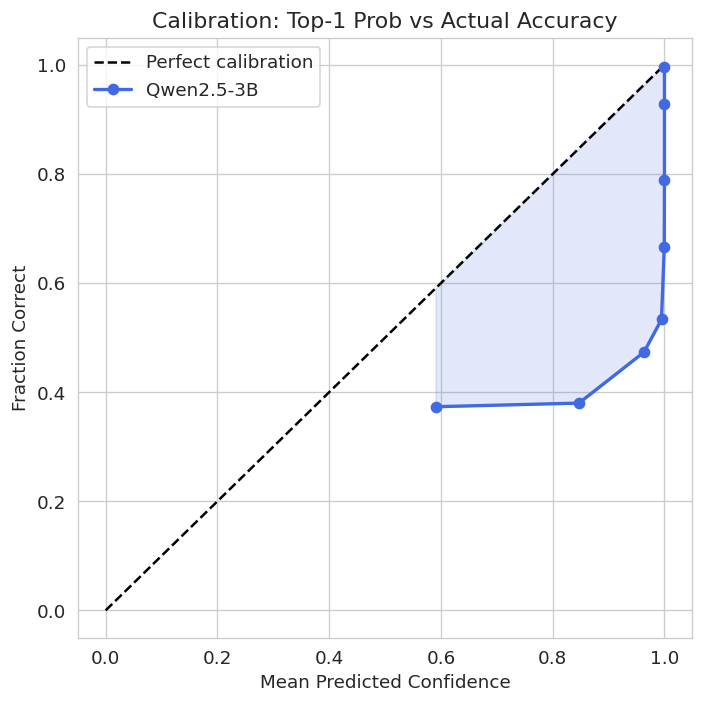

Expected Calibration Error (ECE): 0.2821


In [ ]:
n_bins = 10
fraction_pos, mean_pred = calibration_curve(
    baseline_df["correct_by_probs"], baseline_df["top1_prob"],
    n_bins=n_bins, strategy="quantile",
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.plot(mean_pred, fraction_pos, "o-", color="royalblue", linewidth=2, markersize=6, label="Qwen2.5-3B")
ax.fill_between(mean_pred, fraction_pos, mean_pred, alpha=0.15, color='royalblue')
ax.set_xlabel("Mean Predicted Confidence")
ax.set_ylabel("Fraction Correct")
ax.set_title("Calibration: Top-1 Prob vs Actual Accuracy")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_calibration.png", dpi=150)
plt.show()

# ECE
ece = float(np.mean(np.abs(fraction_pos - mean_pred)))
print(f"Expected Calibration Error (ECE): {ece:.4f}")

---
# Experiment 2 — Confidence Scoring (Two-Pass)

**Goal**: Can the model assess its own confidence?

**Improvement over original**: Instead of changing the answering prompt (which hurt accuracy), we use a **two-pass approach**:
1. **Pass 1**: Normal baseline prompt → get answer and logit-based confidence
2. **Pass 2**: Follow-up message asking *"How confident are you (0-100)?"* → self-reported confidence

This preserves answer quality while still collecting self-assessment data.


In [ ]:
# ── Confidence experiment helpers ──

def build_confidence_followup(question, options, answer_label):
    """Two-pass: model answered normally, now ask for confidence."""
    option_lines = [f"{l}. {t}" for l, t in options.items()]
    valid_labels = list(options.keys())
    user_prompt = (
        f"Question:\n{question}\n\n"
        f"Options:\n" + "\n".join(option_lines) + "\n\n"
        "Answer with only the label."
    )
    return [
        {"role": "system", "content": build_system_prompt(valid_labels)},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": answer_label},
        {"role": "user", "content": (
            f"You answered {answer_label}. "
            "How confident are you in this answer on a scale of 0 to 100? "
            "Reply with ONLY a number between 0 and 100."
        )},
    ]


def parse_confidence(text):
    """Extract a 0-100 number from model output."""
    text = text.strip()
    match = re.search(r"(\d{1,3})", text)
    if match:
        val = int(match.group(1))
        return min(val, 100)
    return None

print("Confidence helpers defined.")

Confidence helpers defined.


In [ ]:
# ── Run Confidence Scoring ──

CONFID_JSONL = RESULTS_DIR / 'confidence_detailed.jsonl'
CONFID_CSV   = RESULTS_DIR / 'confidence_summary.csv'

if CONFID_CSV.exists():
    print('Confidence results exist. Loading...')
    confid_df = pd.read_csv(CONFID_CSV)
else:
    if CONFID_JSONL.exists(): CONFID_JSONL.unlink()
    confid_rows = []
    parse_failures = 0

    for idx, row in tqdm(df.iterrows(), total=len(df), desc='Exp2: Confidence'):
        question = row['question']
        options = dict(zip(row['choice_labels'], row['choice_texts']))
        option_labels = list(options.keys())
        gold = str(row['gold_label']).strip()

        # Pass 1: Normal baseline answer + logit confidence
        msgs = build_messages(question, options)
        out = infer(msgs, options)
        answer_label = out['predicted_by_probs']

        # Pass 2: Ask for self-reported confidence
        conf_msgs = build_confidence_followup(question, options, answer_label)
        conf_prompt = build_prompt_text(conf_msgs)
        conf_inputs = tokenizer(conf_prompt, return_tensors='pt').to(model.device)
        conf_prompt_len = conf_inputs['input_ids'].shape[1]

        with torch.inference_mode():
            conf_out = model.generate(
                **conf_inputs, max_new_tokens=10, do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
        conf_text = tokenizer.decode(conf_out[0][conf_prompt_len:], skip_special_tokens=True).strip()
        self_confidence = parse_confidence(conf_text)
        if self_confidence is None: parse_failures += 1

        correct = int(answer_label == gold)
        record = {
            'row_id': int(idx), 'source': row['source'], 'gold_label': gold,
            'answer_label': answer_label, 'correct': correct,
            'logit_top1_prob': out['top1_prob'], 'logit_margin': out['margin'],
            'logit_entropy': out['entropy_over_labels'],
            'self_confidence': self_confidence, 'conf_text': conf_text,
        }
        with open(CONFID_JSONL, 'a') as f:
            f.write(json.dumps(record) + '\n')
        confid_rows.append(record)

        if idx % 100 == 0:
            c = f'{self_confidence}' if self_confidence is not None else '?'
            print(f'  [{idx}/{len(df)}] ans={answer_label} conf={c} gold={gold} ok={correct}')

    confid_df = pd.DataFrame(confid_rows)
    confid_df.to_csv(CONFID_CSV, index=False)
    print(f'Parse failures: {parse_failures}')
    print(f'Saved: {CONFID_CSV}')

print(f'Confidence: {confid_df.shape}')

Exp2: Confidence:   0%|          | 0/1500 [00:00<?, ?it/s]

  [0/1500] ans=B conf=95 gold=B ok=1
  [100/1500] ans=D conf=85 gold=D ok=1
  [200/1500] ans=A conf=85 gold=A ok=1
  [300/1500] ans=B conf=85 gold=D ok=0
  [400/1500] ans=D conf=85 gold=D ok=1
  [500/1500] ans=A conf=85 gold=D ok=0
  [600/1500] ans=D conf=85 gold=D ok=1
  [700/1500] ans=B conf=85 gold=C ok=0
  [800/1500] ans=B conf=85 gold=B ok=1
  [900/1500] ans=D conf=85 gold=D ok=1
  [1000/1500] ans=A conf=95 gold=A ok=1
  [1100/1500] ans=D conf=95 gold=D ok=1
  [1200/1500] ans=A conf=95 gold=A ok=1
  [1300/1500] ans=A conf=95 gold=A ok=1
  [1400/1500] ans=A conf=95 gold=A ok=1
Parse failures: 0
Saved: results/Qwen2.5-7B-Instruct/confidence_summary.csv
Confidence: (1500, 10)


### 2a — Confidence Scoring Results

In [ ]:
acc = confid_df['correct'].mean()
print('=' * 60)
print('EXPERIMENT 2: CONFIDENCE SCORING RESULTS')
print('=' * 60)
print(f'Accuracy: {acc:.4f}')

valid_c = confid_df.dropna(subset=['self_confidence'])
if len(valid_c) > 0:
    print(f'Parse success rate: {len(valid_c)/len(confid_df)*100:.1f}%')
    print(f'\nMean self-reported confidence (all)    : {valid_c["self_confidence"].mean():.1f}')
    correct_c = valid_c[valid_c['correct'] == 1]
    wrong_c   = valid_c[valid_c['correct'] == 0]
    if len(correct_c) > 0:
        print(f'Mean self-reported confidence (correct): {correct_c["self_confidence"].mean():.1f}')
    if len(wrong_c) > 0:
        print(f'Mean self-reported confidence (wrong)  : {wrong_c["self_confidence"].mean():.1f}')

    if len(valid_c) > 10:
        r_val = valid_c['self_confidence'].corr(valid_c['logit_top1_prob'])
        print(f'\nPearson r(self_confidence, logit_top1_prob): {r_val:.4f}')

    print('\nCalibration by confidence bucket:')
    print(f'{"Range":<15} {"N":>6} {"Accuracy":>10}')
    print('-' * 33)
    for lo, hi in [(0, 25), (25, 50), (50, 75), (75, 90), (90, 100)]:
        if lo == 90:
            bucket = valid_c[(valid_c['self_confidence'] >= lo) & (valid_c['self_confidence'] <= hi)]
        else:
            bucket = valid_c[(valid_c['self_confidence'] >= lo) & (valid_c['self_confidence'] < hi)]
        if len(bucket) > 0:
            print(f'  {lo:3d}-{hi:3d}       {len(bucket):>6} {bucket["correct"].mean():>10.4f}')

print('\nAccuracy by source:')
print(confid_df.groupby('source')['correct'].mean().to_string())

EXPERIMENT 2: CONFIDENCE SCORING RESULTS
Accuracy: 0.7127
Parse success rate: 100.0%

Mean self-reported confidence (all)    : 89.5
Mean self-reported confidence (correct): 90.7
Mean self-reported confidence (wrong)  : 86.7

Pearson r(self_confidence, logit_top1_prob): 0.2040

Calibration by confidence bucket:
Range                N   Accuracy
---------------------------------
    0- 25            2     0.5000
   75- 90          810     0.5679
   90-100          688     0.8837

Accuracy by source:
source
AQUA-RAT    0.408
ARC-Easy    0.976
MMLU        0.892
MedQA       0.540
ReClor      0.496
SciQ        0.964


### 2b — Self-Reported vs Logit-Based Confidence

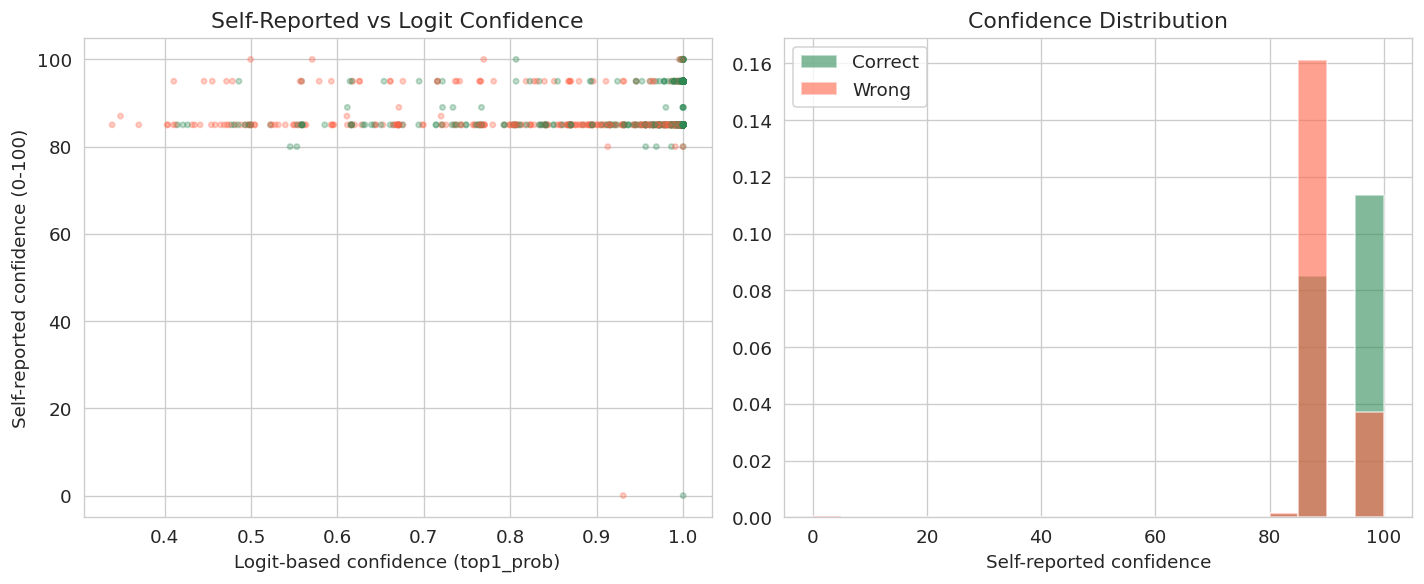

In [ ]:
valid_c = confid_df.dropna(subset=['self_confidence'])

if len(valid_c) > 10:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    colors = ['seagreen' if c else 'tomato' for c in valid_c['correct']]
    ax.scatter(valid_c['logit_top1_prob'], valid_c['self_confidence'], c=colors, alpha=0.3, s=10)
    ax.set_xlabel('Logit-based confidence (top1_prob)')
    ax.set_ylabel('Self-reported confidence (0-100)')
    ax.set_title('Self-Reported vs Logit Confidence')

    ax = axes[1]
    ax.hist(valid_c[valid_c['correct']==1]['self_confidence'], bins=20, alpha=0.6, label='Correct', color='seagreen', density=True)
    ax.hist(valid_c[valid_c['correct']==0]['self_confidence'], bins=20, alpha=0.6, label='Wrong', color='tomato', density=True)
    ax.set_xlabel('Self-reported confidence')
    ax.set_title('Confidence Distribution')
    ax.legend()

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'confidence_analysis.png', dpi=150)
    plt.show()

---
# Experiment 3 — Oracle Retry Reflection

**Goal**: When the model is *actually wrong* (oracle), retry once. Measures the **ceiling** of reflection.

- How often does a second attempt recover the correct answer?
- Does entropy/margin change on retry?
- What is the net accuracy gain?

> **Oracle framing**: We use gold labels to decide *when* to retry. This upper-bounds what reflection could achieve.


In [ ]:
# ── Run Oracle Retry ──
RETRY_CSV = RESULTS_DIR / 'retry_results.csv'

if RETRY_CSV.exists():
    print('Retry results exist. Loading...')
    retry_df = pd.read_csv(RETRY_CSV)
else:
    wrong_indices = baseline_df[baseline_df['correct_by_probs'] == 0]['row_id'].tolist()
    print(f'Model was wrong on {len(wrong_indices)} / {len(baseline_df)} questions. Retrying...')

    retry_rows = []
    for idx in tqdm(wrong_indices, desc='Exp3: Oracle Retry'):
        row = df.iloc[idx]
        question = row['question']
        options = dict(zip(row['choice_labels'], row['choice_texts']))
        gold = normalize_label(str(row['gold_label']))

        orig_row = baseline_df[baseline_df['row_id'] == idx].iloc[0]
        orig_pred = orig_row['pred_by_probs']

        retry_msgs = build_retry_messages(question, options, orig_pred)
        retry_out = infer(retry_msgs, options)
        retry_pred = retry_out['predicted_by_probs']

        retry_rows.append({
            'row_id': idx, 'source': row['source'], 'gold_label': gold,
            'orig_pred': orig_pred, 'retry_pred': retry_pred,
            'retry_correct': int(retry_pred == gold),
            'changed_answer': int(retry_pred != orig_pred),
            'orig_entropy': orig_row['entropy_over_labels'],
            'orig_margin': orig_row['margin'],
            'retry_entropy': retry_out['entropy_over_labels'],
            'retry_margin': retry_out['margin'],
        })

    retry_df = pd.DataFrame(retry_rows)
    retry_df.to_csv(RETRY_CSV, index=False)
    print(f'Saved: {RETRY_CSV}')

print(f'Retry: {len(retry_df)} rows')

Model was wrong on 431 / 1500 questions. Retrying...


Exp3: Oracle Retry:   0%|          | 0/431 [00:00<?, ?it/s]

Saved: results/Qwen2.5-7B-Instruct/retry_results.csv
Retry: 431 rows


### 3a — Recovery Rate & Net Accuracy Gain

Questions retried (model was wrong): 431
Answers that changed after retry   : 421 (97.7%)
  Of changed, now correct           : 43.9%
Total recovered (now correct)       : 185 (42.9% of wrong)
-------------------------------------------------------
Baseline accuracy    : 0.7127
Post-retry accuracy  : 0.8360  (+0.1233)

Per-source recovery:
          n_wrong  recovered  changed  recovery_rate
source                                              
AQUA-RAT      148         43      143       0.290541
ARC-Easy        6          3        6       0.500000
MMLU           27         18       24       0.666667
MedQA         115         60      114       0.521739
ReClor        126         56      126       0.444444
SciQ            9          5        8       0.555556


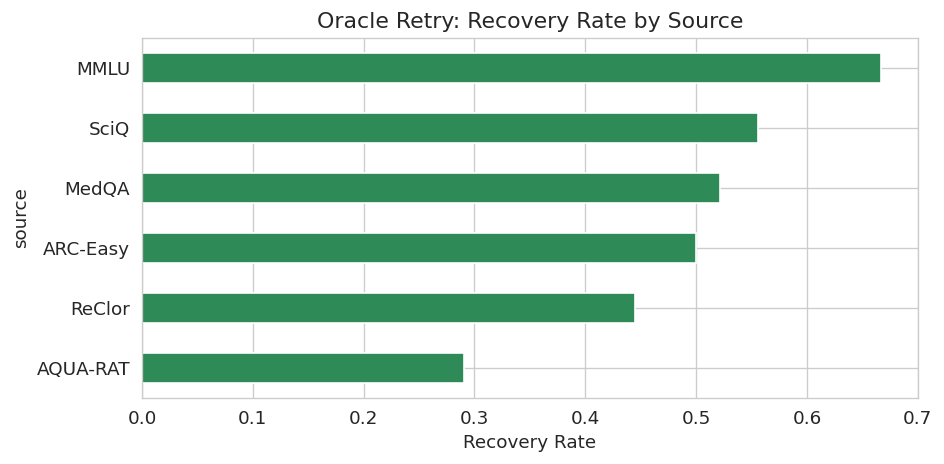

In [ ]:
n_wrong = len(retry_df)
n_total = len(baseline_df)
n_correct = baseline_df["correct_by_probs"].sum()

recovered = retry_df["retry_correct"].sum()
changed = retry_df["changed_answer"].sum()
recovery_rate = recovered / n_wrong if n_wrong > 0 else 0
change_rate = changed / n_wrong if n_wrong > 0 else 0

changed_correct = retry_df[retry_df["changed_answer"] == 1]["retry_correct"].mean()

print("=" * 55)
print(f"Questions retried (model was wrong): {n_wrong}")
print(f"Answers that changed after retry   : {changed} ({change_rate:.1%})")
print(f"  Of changed, now correct           : {changed_correct:.1%}")
print(f"Total recovered (now correct)       : {int(recovered)} ({recovery_rate:.1%} of wrong)")
print("-" * 55)
print(f"Baseline accuracy    : {n_correct/n_total:.4f}")
print(f"Post-retry accuracy  : {(n_correct + recovered)/n_total:.4f}  (+{recovered/n_total:.4f})")
print("=" * 55)

# Per-source
per_source = retry_df.groupby("source").agg(
    n_wrong=("retry_correct", "count"),
    recovered=("retry_correct", "sum"),
    changed=("changed_answer", "sum"),
).assign(
    recovery_rate=lambda d: d["recovered"] / d["n_wrong"],
)
print("\nPer-source recovery:")
print(per_source.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
per_source["recovery_rate"].sort_values().plot.barh(ax=ax, color="seagreen")
ax.set_xlabel("Recovery Rate")
ax.set_title("Oracle Retry: Recovery Rate by Source")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "retry_recovery_per_source.png", dpi=150)
plt.show()

### 3b — Uncertainty Shift (Original vs Retry)

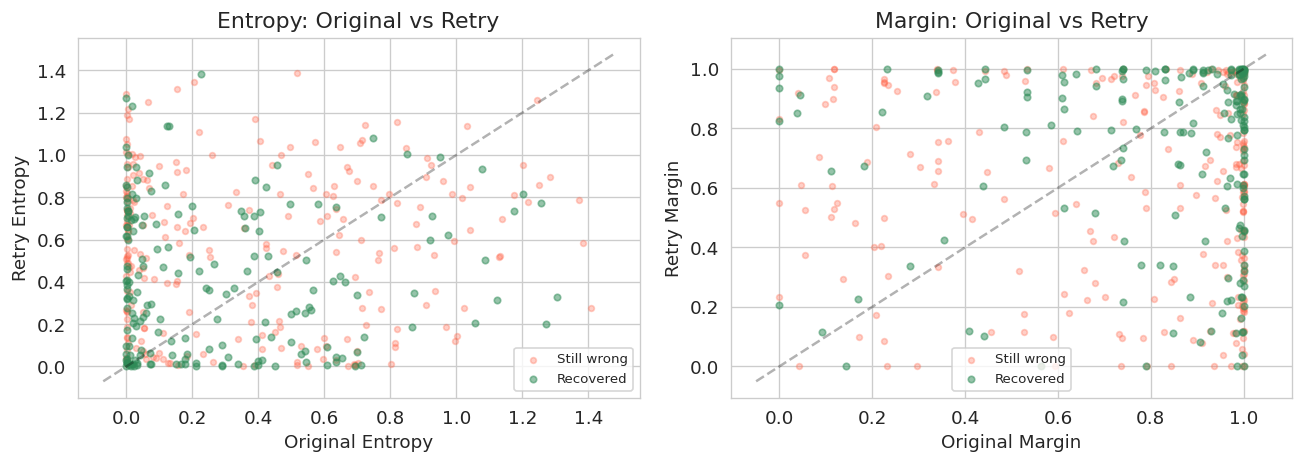

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (orig_col, retry_col, label) in zip(axes, [
    ("orig_entropy", "retry_entropy", "Entropy"),
    ("orig_margin", "retry_margin", "Margin"),
]):
    rec_mask = retry_df["retry_correct"] == 1
    ax.scatter(retry_df.loc[~rec_mask, orig_col], retry_df.loc[~rec_mask, retry_col],
              alpha=0.3, s=12, color="tomato", label="Still wrong")
    ax.scatter(retry_df.loc[rec_mask, orig_col], retry_df.loc[rec_mask, retry_col],
              alpha=0.5, s=15, color="seagreen", label="Recovered")
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, "k--", alpha=0.3)
    ax.set_xlabel(f"Original {label}")
    ax.set_ylabel(f"Retry {label}")
    ax.set_title(f"{label}: Original vs Retry")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "retry_uncertainty_shift.png", dpi=150)
plt.show()

---
# Experiment 4 — When to Reflect

**Goal**: Can we predict whether the model is wrong using only uncertainty signals?

Binary classification: label 1 = model wrong, label 0 = model correct.

**Signals**: entropy, margin, top1_prob (all from baseline logits — no extra inference needed).


In [ ]:
# ── ROC AUC for each signal ──
target = 1 - baseline_df['correct_by_probs'].values  # 1 = wrong

signal_configs = {
    'entropy_over_labels': baseline_df['entropy_over_labels'].values,
    'entropy_over_vocab':  baseline_df['entropy_over_vocab'].values,
    '1 - margin':          1 - baseline_df['margin'].values,
    '1 - top1_prob':       1 - baseline_df['top1_prob'].values,
}

# Add self-reported confidence from Experiment 2
conf_merged = baseline_df[['row_id']].merge(
    confid_df[['row_id', 'self_confidence']], on='row_id', how='left'
)
self_conf_scores = 1 - (conf_merged['self_confidence'].fillna(50).values / 100)
signal_configs['1 - self_confidence'] = self_conf_scores

auc_results = {}
print('ROC AUC and Average Precision:')
print('-' * 65)
for name, scores in signal_configs.items():
    auc = roc_auc_score(target, scores)
    ap = average_precision_score(target, scores)
    auc_results[name] = (auc, ap)
    print(f'  {name:<30} AUC={auc:.4f}   AP={ap:.4f}')

print()
print('Key comparison: logit signals vs self-reported confidence')
logit_best = max(v[0] for k, v in auc_results.items() if 'self' not in k)
self_auc = auc_results['1 - self_confidence'][0]
print(f'  Best logit signal AUC:     {logit_best:.4f}')
print(f'  Self-confidence AUC:       {self_auc:.4f}')
print(f'  Difference:                {logit_best - self_auc:+.4f}')

ROC AUC and Average Precision:
-----------------------------------------------------------------
  entropy_over_labels            AUC=0.8435   AP=0.6233
  entropy_over_vocab             AUC=0.8437   AP=0.6238
  1 - margin                     AUC=0.8404   AP=0.5955
  1 - top1_prob                  AUC=0.8416   AP=0.6112
  1 - self_confidence            AUC=0.6897   AP=0.4067

Key comparison: logit signals vs self-reported confidence
  Best logit signal AUC:     0.8437
  Self-confidence AUC:       0.6897
  Difference:                +0.1540


### 4a — ROC Curves

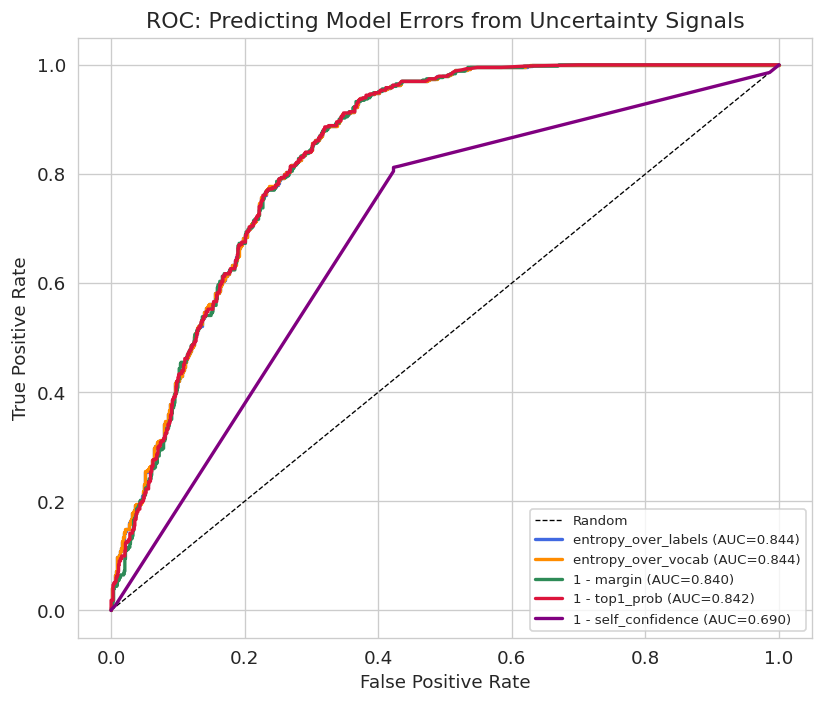

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')

colors = ['royalblue', 'darkorange', 'seagreen', 'crimson', 'purple']
for (name, scores), color in zip(signal_configs.items(), colors):
    fpr, tpr, _ = roc_curve(target, scores)
    auc = auc_results[name][0]
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC: Predicting Model Errors from Uncertainty Signals')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'when_to_reflect_roc.png', dpi=150)
plt.show()

### 4b — Threshold Sweep: Accuracy vs Reflection Rate

Empirical recovery rate: 0.429


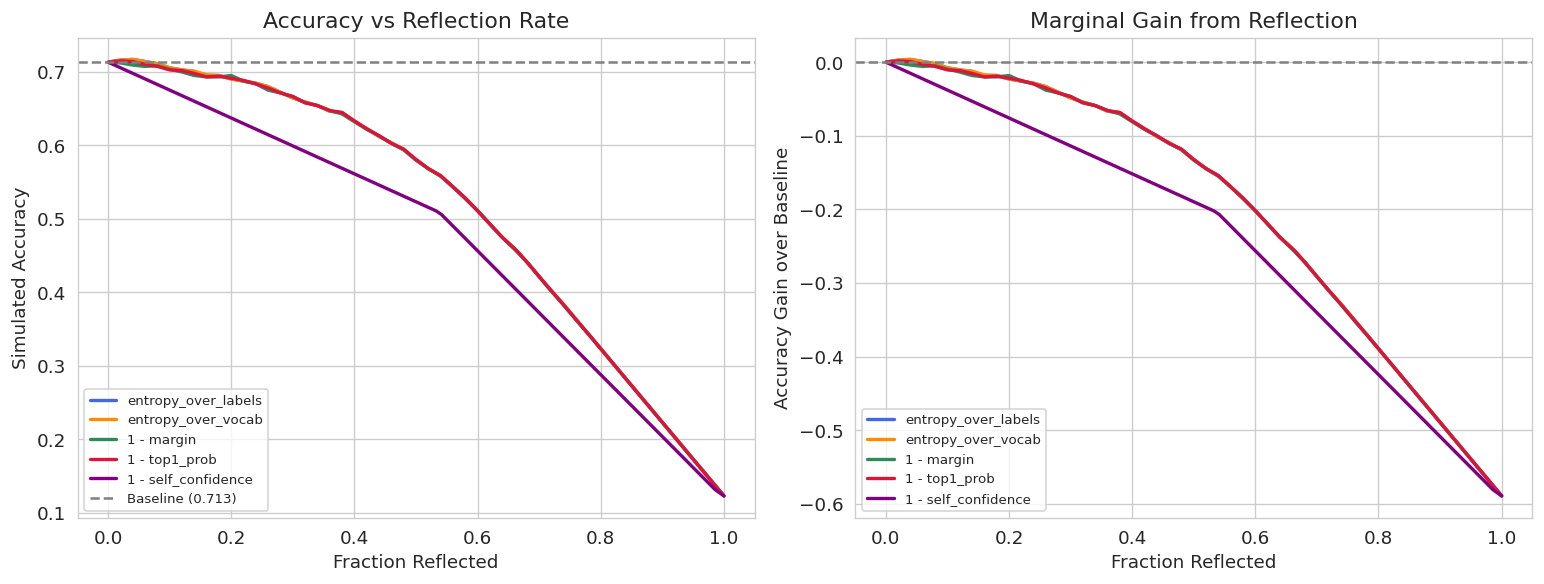

In [ ]:
try:
    recovery_rate_emp = retry_df["retry_correct"].mean()
except: recovery_rate_emp = 0.35
print(f"Empirical recovery rate: {recovery_rate_emp:.3f}")

n_total = len(baseline_df)
baseline_acc = baseline_df["correct_by_probs"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for (name, scores), color in zip(signal_configs.items(), colors):
    thresholds = np.percentile(scores, np.arange(0, 101, 2))
    reflect_fracs, sim_accs = [], []
    for t in thresholds:
        reflect_mask = scores >= t
        n_reflect = reflect_mask.sum()
        reflect_fracs.append(n_reflect / n_total)
        n_correct_no_reflect = ((~reflect_mask) & (target == 0)).sum()
        n_recovered = (reflect_mask & (target == 1)).sum() * recovery_rate_emp
        n_kept_wrong = (reflect_mask & (target == 0)).sum()
        sim_accs.append((n_correct_no_reflect + n_recovered + 0) / n_total)

    axes[0].plot(reflect_fracs, sim_accs, color=color, linewidth=2, label=name)
    axes[1].plot(reflect_fracs, [s - baseline_acc for s in sim_accs], color=color, linewidth=2, label=name)

axes[0].axhline(baseline_acc, color="gray", ls="--", label=f"Baseline ({baseline_acc:.3f})")
axes[0].set_xlabel("Fraction Reflected")
axes[0].set_ylabel("Simulated Accuracy")
axes[0].set_title("Accuracy vs Reflection Rate")
axes[0].legend(fontsize=8)

axes[1].axhline(0, color="gray", ls="--")
axes[1].set_xlabel("Fraction Reflected")
axes[1].set_ylabel("Accuracy Gain over Baseline")
axes[1].set_title("Marginal Gain from Reflection")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "when_to_reflect_threshold_sweep.png", dpi=150)
plt.show()

### 4c — Per-Source AUC Heatmap

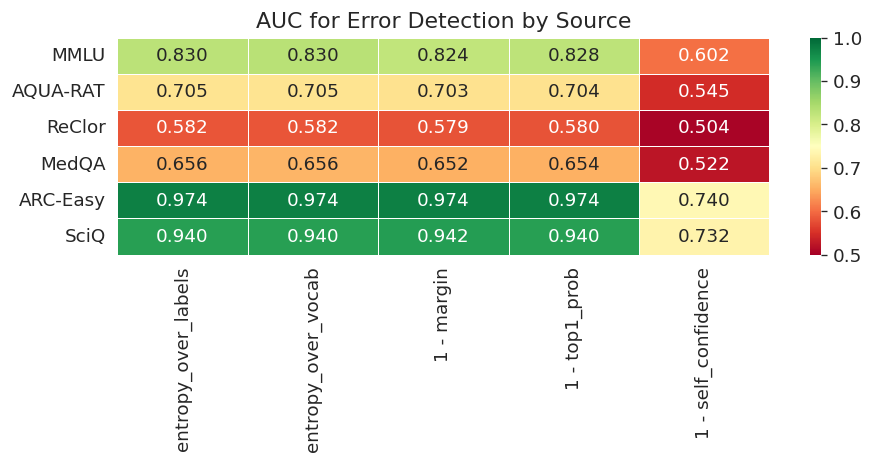

In [ ]:
sources = baseline_df["source"].unique()
signal_names = list(signal_configs.keys())
auc_matrix = pd.DataFrame(index=sources, columns=signal_names, dtype=float)

for source in sources:
    mask = baseline_df["source"] == source
    tgt_src = target[mask]
    if tgt_src.sum() == 0 or tgt_src.sum() == len(tgt_src): continue
    for name, scores in signal_configs.items():
        try: auc_matrix.loc[source, name] = roc_auc_score(tgt_src, scores[mask])
        except: auc_matrix.loc[source, name] = float('nan')

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(auc_matrix.astype(float), annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=0.5, vmax=1.0, ax=ax, linewidths=0.5)
ax.set_title("AUC for Error Detection by Source")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "when_to_reflect_auc_heatmap.png", dpi=150)
plt.show()

### 4d — Optimal Threshold (F1)

In [ ]:
header = f"{'Signal':<25} {'Best Thresh':>12} {'F1':>8} {'Precision':>11} {'Recall':>9}"
print(header)
print('-' * 68)

for name, scores in signal_configs.items():
    thresholds = np.percentile(scores, np.arange(5, 96, 1))
    best_f1, best_thresh, best_prec, best_rec = 0, None, 0, 0
    for thresh in thresholds:
        preds = (scores >= thresh).astype(int)
        if preds.sum() == 0: continue
        f = f1_score(target, preds, zero_division=0)
        if f > best_f1:
            best_f1 = f
            best_thresh = thresh
            from sklearn.metrics import precision_score, recall_score
            best_prec = precision_score(target, preds, zero_division=0)
            best_rec = recall_score(target, preds, zero_division=0)
    print(f'  {name:<23} {best_thresh:>12.4f} {best_f1:>8.4f} {best_prec:>11.4f} {best_rec:>9.4f}')

Signal                     Best Thresh       F1   Precision    Recall
--------------------------------------------------------------------
  entropy_over_labels           0.0011   0.6586      0.5264    0.8794
  entropy_over_vocab            0.0011   0.6586      0.5264    0.8794
  1 - margin                    0.0002   0.6586      0.5264    0.8794
  1 - top1_prob                 0.0001   0.6603      0.5278    0.8817
  1 - self_confidence           0.1100   0.5648      0.4323    0.8144


### 4e — Confidence Binning: Error Rate by Decile

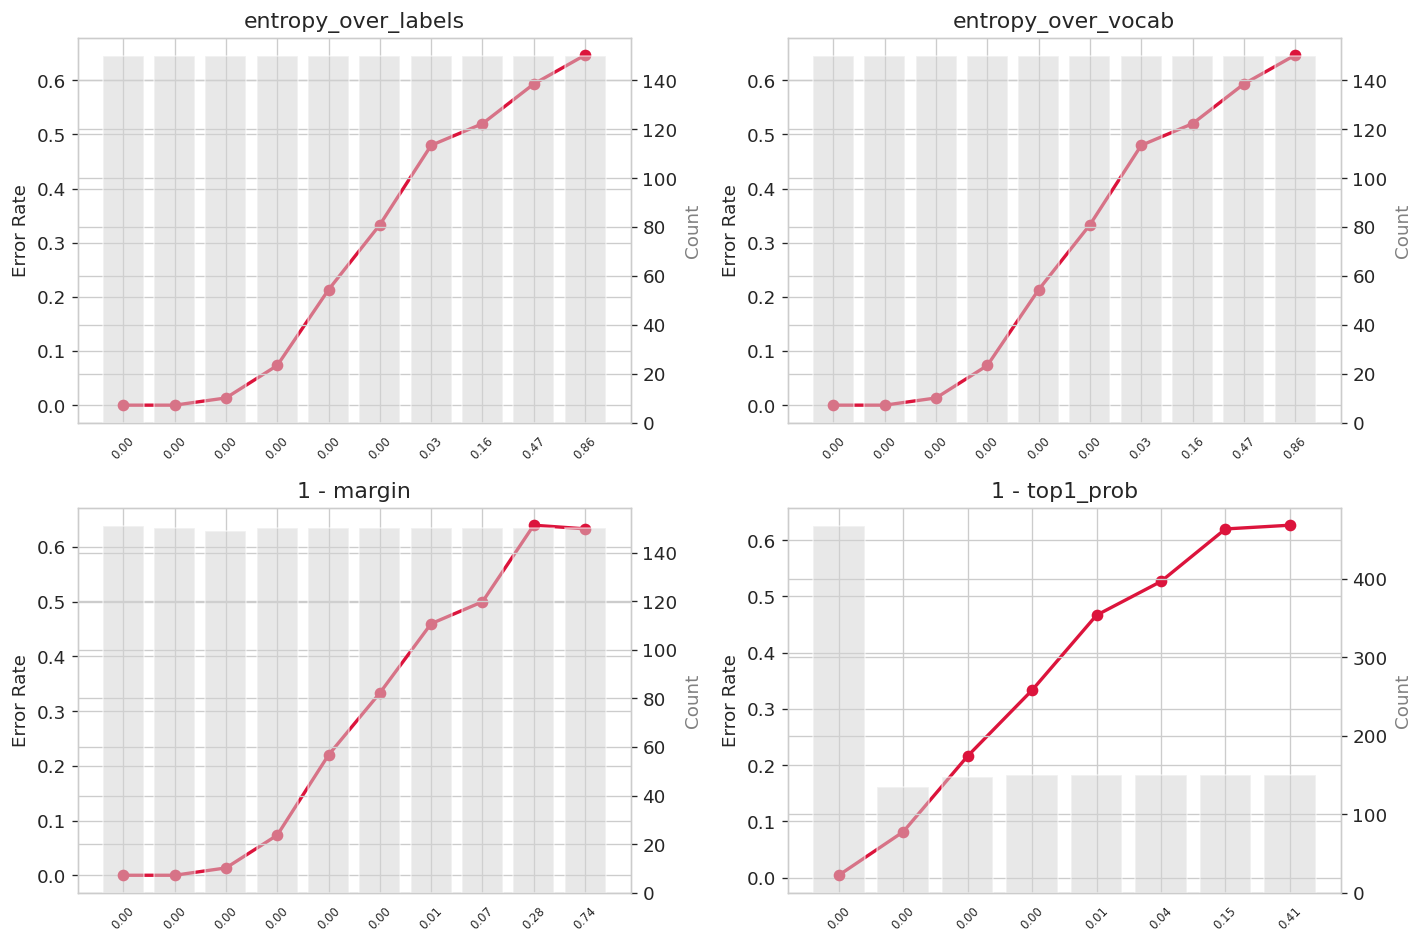

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
n_bins = 10
for ax, (name, scores) in zip(axes.flatten(), signal_configs.items()):
    bin_labels = pd.qcut(pd.Series(scores), q=n_bins, labels=False, duplicates='drop')
    bin_centers, error_rates, counts = [], [], []
    for b in sorted(bin_labels.unique()):
        mask = bin_labels == b
        bin_centers.append(scores[mask].mean())
        error_rates.append(target[mask].mean())
        counts.append(mask.sum())

    ax2 = ax.twinx()
    ax2.bar(range(len(bin_centers)), counts, color="lightgray", alpha=0.5, label="Count")
    ax2.set_ylabel("Count", color="gray")
    ax.plot(range(len(bin_centers)), error_rates, "o-", color="crimson", linewidth=2, label="Error rate")
    ax.set_ylabel("Error Rate")
    ax.set_title(name)
    ax.set_xticks(range(len(bin_centers)))
    ax.set_xticklabels([f"{c:.2f}" for c in bin_centers], rotation=45, fontsize=7)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "when_to_reflect_decile_error.png", dpi=150)
plt.show()

---
## Summary Dashboard

In [ ]:
print('=' * 65)
print('  MCQ UNCERTAINTY EXPERIMENTS — SUMMARY')
print('=' * 65)

print('\nExperiment 1 — Baseline')
print(f'  Accuracy (greedy):   {baseline_df["correct_generated"].mean():.4f}')
print(f'  Accuracy (prob-max): {baseline_df["correct_by_probs"].mean():.4f}')
print(f'  ECE:                 {ece:.4f}')

print('\nExperiment 2 — Confidence Scoring')
print(f'  Accuracy:            {confid_df["correct"].mean():.4f}')
valid_c = confid_df.dropna(subset=['self_confidence'])
if len(valid_c) > 0:
    print(f'  Mean self-confidence: {valid_c["self_confidence"].mean():.1f}')
    print(f'  r(self, logit):      {valid_c["self_confidence"].corr(valid_c["logit_top1_prob"]):.4f}')

print('\nExperiment 3 — Oracle Retry')
print(f'  Questions retried:   {len(retry_df)}')
print(f'  Recovery rate:       {retry_df["retry_correct"].mean():.4f}')
n_correct = baseline_df['correct_by_probs'].sum()
recovered = retry_df['retry_correct'].sum()
print(f'  Post-retry accuracy: {(n_correct + recovered)/len(baseline_df):.4f}  (+{recovered/len(baseline_df):.4f})')

print('\nExperiment 4 — When to Reflect (AUC for error prediction)')
for name, (auc, ap) in auc_results.items():
    print(f'  {name:<30} AUC={auc:.4f}  AP={ap:.4f}')

print('\n' + '=' * 65)
print(f'\nAll results saved to: {RESULTS_DIR}/')
for p in sorted(RESULTS_DIR.glob('*')):
    print(f'  {p.name}')
print('=' * 65)

  MCQ UNCERTAINTY EXPERIMENTS — SUMMARY

Experiment 1 — Baseline
  Accuracy (greedy):   0.7127
  Accuracy (prob-max): 0.7127
  ECE:                 0.2821

Experiment 2 — Confidence Scoring
  Accuracy:            0.7127
  Mean self-confidence: 89.5
  r(self, logit):      0.2040

Experiment 3 — Oracle Retry
  Questions retried:   431
  Recovery rate:       0.4292
  Post-retry accuracy: 0.8360  (+0.1233)

Experiment 4 — When to Reflect (AUC for error prediction)
  entropy_over_labels            AUC=0.8435  AP=0.6233
  entropy_over_vocab             AUC=0.8437  AP=0.6238
  1 - margin                     AUC=0.8404  AP=0.5955
  1 - top1_prob                  AUC=0.8416  AP=0.6112
  1 - self_confidence            AUC=0.6897  AP=0.4067


All results saved to: results/Qwen2.5-7B-Instruct/
  baseline.jsonl
  baseline_accuracy_per_source.png
  baseline_calibration.png
  baseline_signal_distributions.png
  baseline_summary.csv
  confidence_analysis.png
  confidence_detailed.jsonl
  confidence_su

In [ ]:
import shutil

# Create a zip archive of the results directory
zip_filename = RESULTS_DIR.parent / 'results.zip'
shutil.make_archive(zip_filename.stem, 'zip', RESULTS_DIR)
print(f"Results compressed to {zip_filename}. You can now download it from the Colab file browser.")

Results compressed to results/results.zip. You can now download it from the Colab file browser.
